In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Load Dataset
file_path = '/workspaces/BlizzardX/Data/Final_Processed.csv'
station_df = pd.read_csv(file_path)

# Exclude non-numeric columns
exclude_cols = ['DATE', 'Station_ID', 'NAME', 'Season']
num_cols = station_df.select_dtypes(include=['number']).columns.difference(exclude_cols)

# Check Missing Values
missing_values = station_df[num_cols].isnull().sum()
print("\nMissing Values Per Feature:\n", missing_values[missing_values > 0])

# Detect Outliers Using IQR & Z-score
outliers_summary = []

for station in station_df['Station_ID'].unique():
    station_data = station_df[station_df['Station_ID'] == station]

    # IQR Method
    Q1 = station_data[num_cols].quantile(0.25)
    Q3 = station_data[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((station_data[num_cols] < (Q1 - 1.5 * IQR)) | (station_data[num_cols] > (Q3 + 1.5 * IQR))).sum()

    # Z-score Method
    z_scores = np.abs(stats.zscore(station_data[num_cols], nan_policy='omit'))
    zscore_outliers = (z_scores > 3).sum(axis=0)

    # Store Results
    for feature in num_cols:
        outliers_summary.append({
            'Station_ID': station,
            'Feature': feature,
            'IQR Outliers': iqr_outliers[feature],
            'Z-score Outliers': zscore_outliers[feature]
        })

# Convert to DataFrame
outliers_summary_df = pd.DataFrame(outliers_summary)
print("\nOutlier Summary:\n", outliers_summary_df)

# Save Summary for Reference
outliers_summary_df.to_csv('/workspaces/BlizzardX/Data/Outlier_Summary.csv', index=False)
print("\nOutlier Summary Saved Successfully!")


In [16]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Load data
station_df = pd.read_csv('/workspaces/BlizzardX/Data/processed_data.csv')

# Exclude non-numeric and categorical columns
exclude_cols = ['DATE', 'ID', 'NAME', 'Season']
num_cols = station_df.select_dtypes(include=['number']).columns.difference(exclude_cols)

# Check Missing Values
missing_values = station_df[num_cols].isnull().sum()
print("\nMissing Values Per Feature:\n", missing_values[missing_values > 0])

# Filter out low-variance features (avoid catastrophic cancellation in Z-score calculation)
low_variance_cols = station_df[num_cols].std() < 1e-6  # Features with near-zero variance
valid_num_cols = num_cols[~low_variance_cols]

print(f"\nExcluding {low_variance_cols.sum()} low-variance features: {list(num_cols[low_variance_cols])}")

# Create an empty list to store results
outliers_list = []

# Process each station separately
for station in station_df['ID'].unique():
    station_data = station_df[station_df['ID'] == station]

    # IQR Method
    Q1 = station_data[valid_num_cols].quantile(0.25)
    Q3 = station_data[valid_num_cols].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((station_data[valid_num_cols] < (Q1 - 1.5 * IQR)) | (station_data[valid_num_cols] > (Q3 + 1.5 * IQR))).sum()

    # Z-score Method (excluding low-variance features)
    z_scores = stats.zscore(station_data[valid_num_cols], nan_policy='omit')

    # Convert to DataFrame to avoid indexing issues
    if isinstance(z_scores, np.ndarray):  
        z_scores = pd.DataFrame(np.abs(z_scores), columns=valid_num_cols, index=station_data.index)
        zscore_outliers = (z_scores > 3).sum()
    else:
        zscore_outliers = pd.Series(0, index=valid_num_cols)  # If z_scores fails, set outliers to 0

    # Store results
    for feature in valid_num_cols:
        outliers_list.append({
            'Station_ID': station,
            'Feature': feature,
            'IQR Outliers': int(iqr_outliers.get(feature, 0)),  # Ensure valid indexing
            'Z-score Outliers': int(zscore_outliers.get(feature, 0))  # Handle missing features
        })

# Convert results to DataFrame
outliers_summary = pd.DataFrame(outliers_list)

# Display station-wise outlier summary
print(outliers_summary)



Missing Values Per Feature:
 PRCP    113
SNOW    773
SNWD    899
TMAX    185
TMIN    187
dtype: int64

Excluding 0 low-variance features: []
     Station_ID    Feature  IQR Outliers  Z-score Outliers
0   USC00272302  ELEVATION             0                 0
1   USC00272302   LATITUDE             0                 0
2   USC00272302  LONGITUDE             0                 0
3   USC00272302       PRCP          1095               160
4   USC00272302       SNOW           367               116
..          ...        ...           ...               ...
75  USW00014755       PRCP          2856               603
76  USW00014755       SNOW          4781               650
77  USW00014755       SNWD          2117               535
78  USW00014755       TMAX            25                30
79  USW00014755       TMIN            15                22

[80 rows x 4 columns]


/tmp/ipykernel_5023/4217591606.py:36: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = stats.zscore(station_data[valid_num_cols], nan_policy='omit')
/tmp/ipykernel_5023/4217591606.py:36: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = stats.zscore(station_data[valid_num_cols], nan_policy='omit')
/tmp/ipykernel_5023/4217591606.py:36: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = stats.zscore(station_data[valid_num_cols], nan_policy='omit')
/tmp/ipykernel_5023/4217591606.py:36: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs wh

In [17]:
outliers_summary.to_csv('/workspaces/BlizzardX/Data/outliers_summary.csv', index=False)

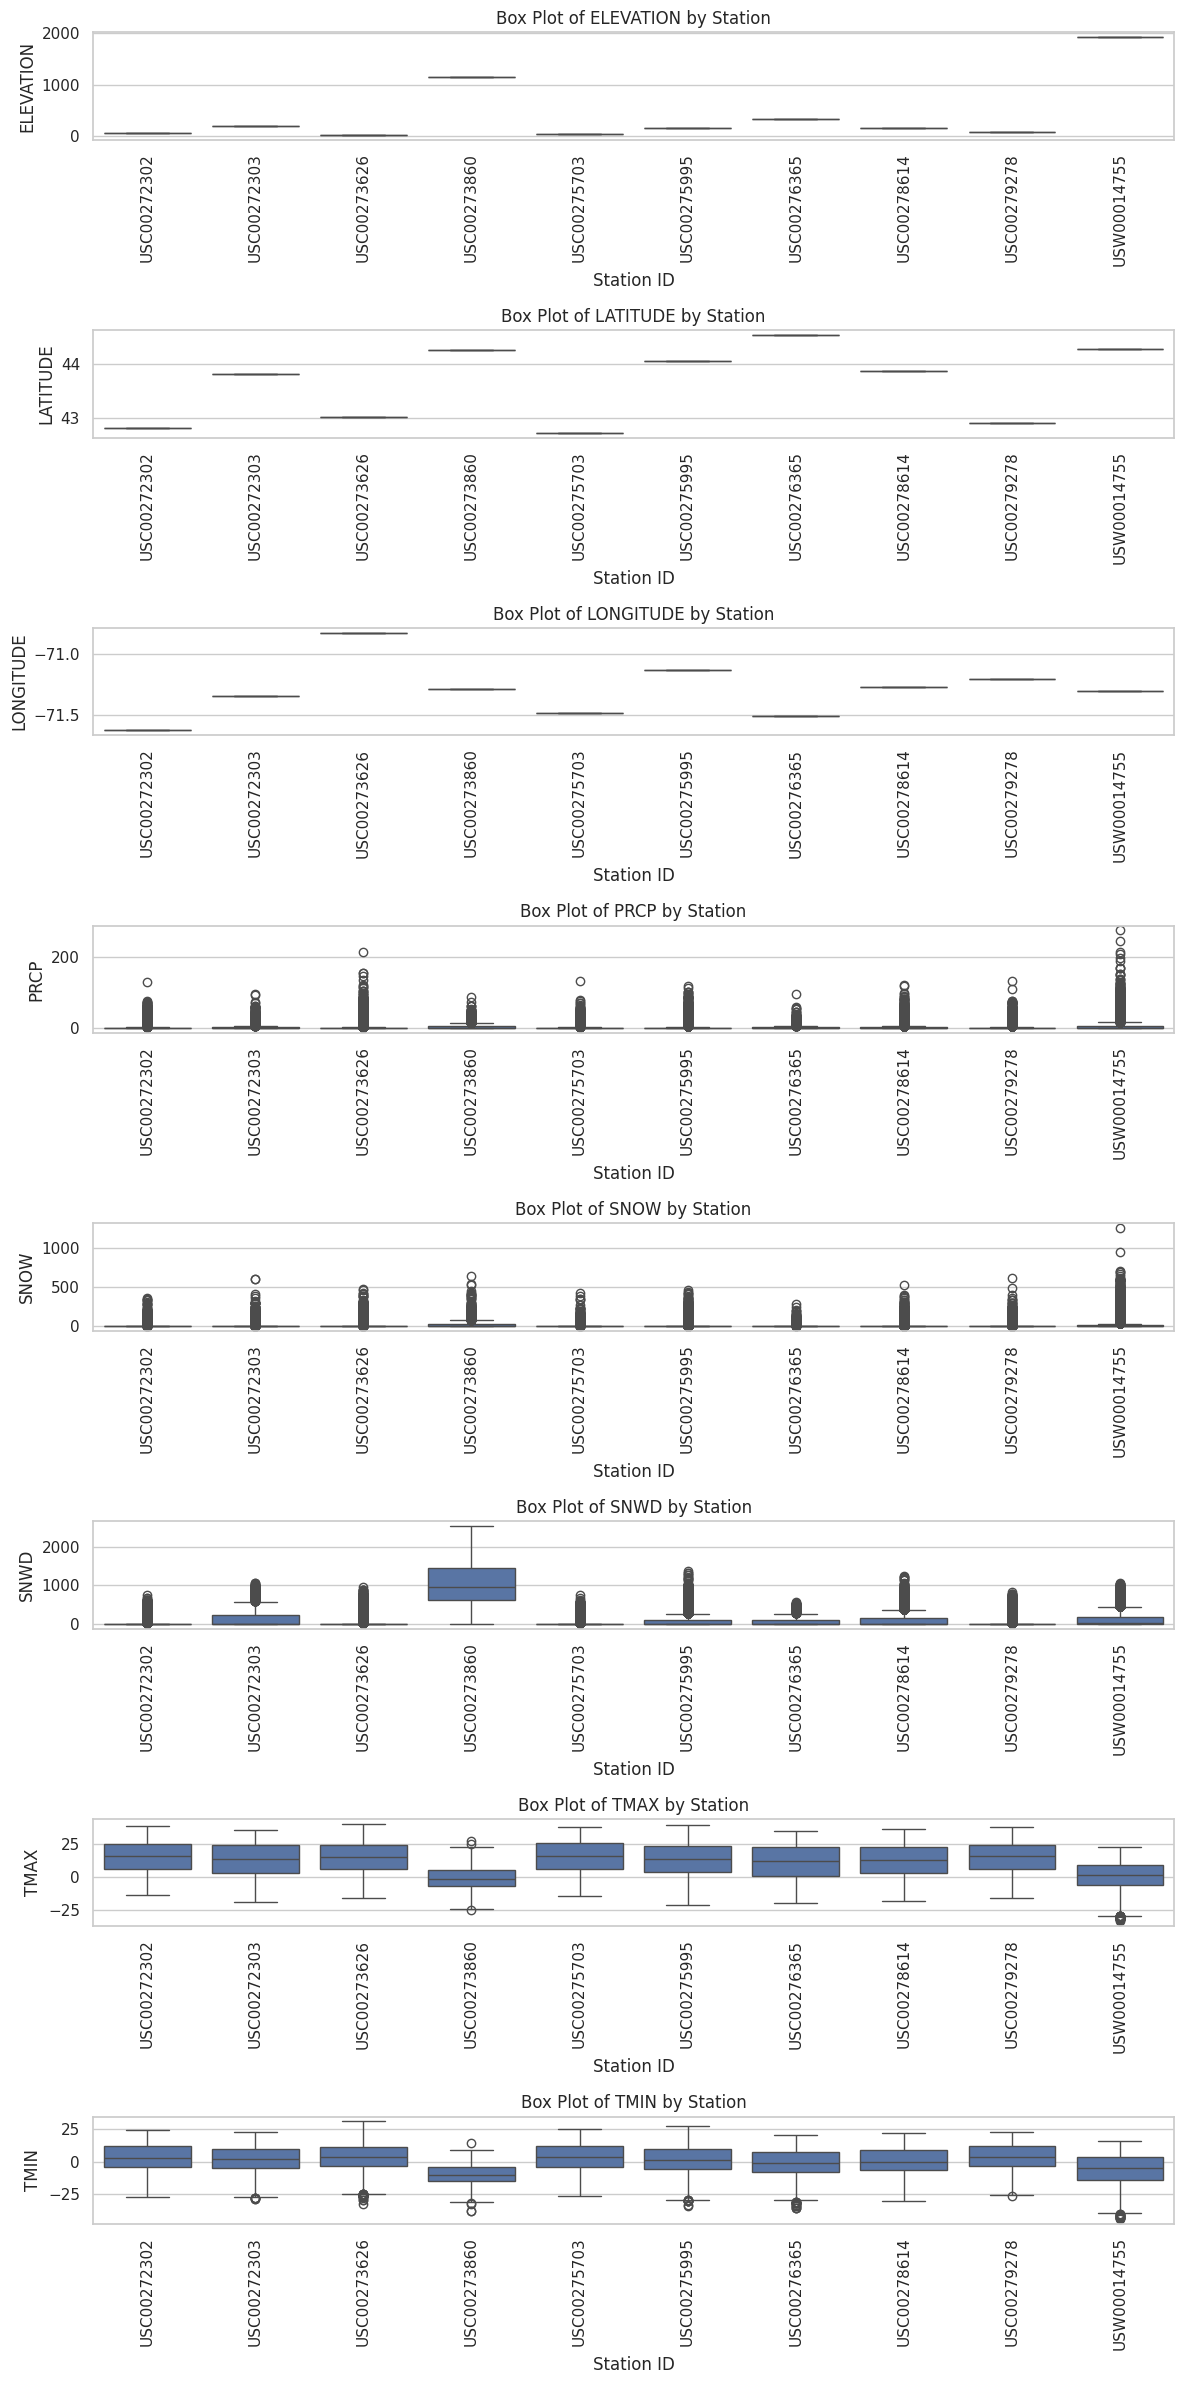

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Define number of stations and features to plot
num_stations = station_df["ID"].nunique()
num_features = len(num_cols)

# Create a figure with subplots
fig, axes = plt.subplots(nrows=num_features, ncols=1, figsize=(12, num_features * 3))

# Plot each feature as a boxplot
for i, feature in enumerate(num_cols):
    ax = axes[i] if num_features > 1 else axes
    sns.boxplot(data=station_df, x="ID", y=feature, ax=ax)
    ax.set_title(f"Box Plot of {feature} by Station")
    ax.set_xlabel("Station ID")
    ax.set_ylabel(feature)
    ax.tick_params(axis="x", rotation=90)  # Rotate x-axis labels for better readability

plt.tight_layout()
plt.show()
